In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline
pd.set_option("display.width", 120)

## Lab 1: Boston Housing Pricing
**Context:** Predict median house values using neighborhood features.
**Dataset:** `fetch_openml(name='boston', version=1)`

**Tasks:**
1. Load dataset and split into 80% train / 20% test
2. Scale features using StandardScaler
3. Train linear regression model
4. Calculate MSE and R² on test set
5. Print top 3 most important features

> ملحوظة: `fetch_openml` بيحتاج اتصال بـ openml.org اللي مش متاح هنا، فبنجيب نفس الداتا (506 samples, نفس الأعمدة) من مصدر بديل موثوق على GitHub.

In [2]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston = pd.read_csv(boston_url)
boston.columns = [c.lower() for c in boston.columns]

X1 = boston.drop(columns=["medv"])
y1 = boston["medv"]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

scaler_1 = StandardScaler()
X1_train_scaled = scaler_1.fit_transform(X1_train)
X1_test_scaled = scaler_1.transform(X1_test)

model_1 = LinearRegression()
model_1.fit(X1_train_scaled, y1_train)

y1_pred = model_1.predict(X1_test_scaled)
mse_1 = mean_squared_error(y1_test, y1_pred)
r2_1 = r2_score(y1_test, y1_pred)

coef_importance_1 = pd.Series(np.abs(model_1.coef_), index=X1.columns).sort_values(ascending=False)

print(f"MSE: {mse_1:.2f}")
print(f"R^2: {r2_1:.3f}")
print("Top 3 most important features (by |scaled coefficient|):")
print(coef_importance_1.head(3))

MSE: 24.29
R^2: 0.669
Top 3 most important features (by |scaled coefficient|):
lstat    3.611658
rm       3.145240
dis      3.081908
dtype: float64


## Lab 2: Diabetes Progression Prediction
**Context:** Predict disease progression using multiple health indicators.
**Dataset:** `load_diabetes()` (scikit-learn)

**Tasks:**
1. Load dataset and examine feature distributions
2. Create feature interaction: BMI × Blood Pressure
3. Train model with/without interaction term
4. Compare R² scores for both models
5. Plot residuals vs predictions

Feature distributions (describe):
               age           sex           bmi            bp            s1            s2            s3            s4  \
mean -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17  3.918434e-17 -5.777179e-18 -9.042540e-18   
std   4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min  -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01 -1.156131e-01 -1.023071e-01 -7.639450e-02   
max   1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01  1.987880e-01  1.811791e-01  1.852344e-01   

                s5            s6  
mean  9.293722e-17  1.130318e-17  
std   4.761905e-02  4.761905e-02  
min  -1.260971e-01 -1.377672e-01  
max   1.335973e-01  1.356118e-01  

R^2 without interaction term: 0.4526
R^2 with BMI x BloodPressure interaction: 0.4790
إضافة الـ interaction term حسّنت الأداء شوية.


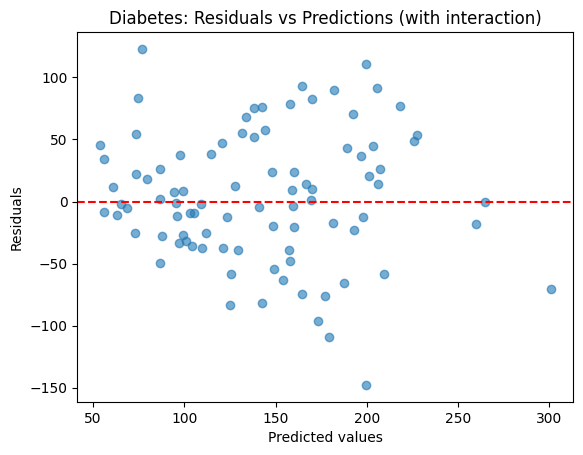

In [3]:
diabetes = load_diabetes(as_frame=True)
df2 = diabetes.frame.copy()
X2_base = df2.drop(columns=["target"])
y2 = df2["target"]

print("Feature distributions (describe):")
print(X2_base.describe().loc[["mean", "std", "min", "max"]])

# Model WITHOUT interaction
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_base, y2, test_size=0.2, random_state=42)
model_2_no_int = LinearRegression()
model_2_no_int.fit(X2_train, y2_train)
r2_2_no_int = r2_score(y2_test, model_2_no_int.predict(X2_test))

# Model WITH interaction: BMI x Blood Pressure (bmi x bp)
X2_int = X2_base.copy()
X2_int["bmi_bp_interaction"] = X2_int["bmi"] * X2_int["bp"]
X2_train_i, X2_test_i, y2_train_i, y2_test_i = train_test_split(X2_int, y2, test_size=0.2, random_state=42)
model_2_int = LinearRegression()
model_2_int.fit(X2_train_i, y2_train_i)
y2_pred_int = model_2_int.predict(X2_test_i)
r2_2_int = r2_score(y2_test_i, y2_pred_int)

print(f"\nR^2 without interaction term: {r2_2_no_int:.4f}")
print(f"R^2 with BMI x BloodPressure interaction: {r2_2_int:.4f}")
print("إضافة الـ interaction term حسّنت الأداء شوية." if r2_2_int > r2_2_no_int
      else "إضافة الـ interaction term ملحسنتش الأداء.")

residuals_2 = y2_test_i - y2_pred_int
plt.scatter(y2_pred_int, residuals_2, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted values"); plt.ylabel("Residuals")
plt.title("Diabetes: Residuals vs Predictions (with interaction)")
plt.show()

## Lab 3: California Housing Prices
**Context:** Predict median house values using California census data.
**Dataset:** `fetch_california_housing()` (scikit-learn)

**Tasks:**
1. Add new feature: Rooms per person (AveRooms / Population)
2. Handle outliers in MedInc (cap at 97th percentile)
3. Train model and calculate VIF for multicollinearity
4. Plot feature importance
5. Predict price for: MedInc=4.0, HouseAge=20, AveRooms=5, Population=1200, AveOccup=2.5

> ملحوظة: `fetch_california_housing()` بيحتاج تحميل من figshare.com اللي مش متاح هنا، فبنجيب نفس الداتا بالظبط من مرآة (mirror) على GitHub.

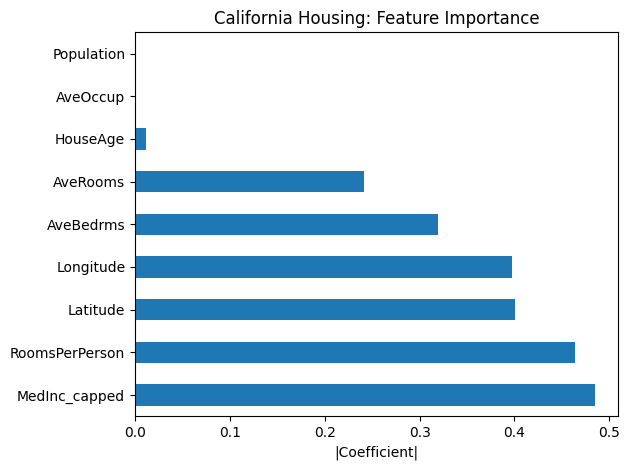

VIF per feature:
       feature        VIF
     Longitude 674.590552
      Latitude 579.350890
      AveRooms  55.681824
     AveBedrms  50.687746
RoomsPerPerson  22.151423
 MedInc_capped  14.905635
      HouseAge   7.212496
    Population   3.009605
      AveOccup   1.107673

Top 3 important features:
MedInc_capped     0.485365
RoomsPerPerson    0.464002
Latitude          0.400235
dtype: float64

Predicted median house value: $217,161.13
(AveBedrms, Latitude, Longitude معملهاش السؤال قيمة، فاتحطلها متوسط الداتاست)


In [4]:
cali_url = "https://raw.githubusercontent.com/javascriptdata/scikit.js/refs/heads/main/docs/static/data/california_housing.csv"
df3 = pd.read_csv(cali_url)

# Feature: rooms per person = AveRooms / AveOccup
df3["RoomsPerPerson"] = df3["AveRooms"] / df3["AveOccup"]

# Cap MedInc outliers at the 97th percentile
cap_97 = df3["MedInc"].quantile(0.97)
df3["MedInc_capped"] = df3["MedInc"].clip(upper=cap_97)

features_3 = ["MedInc_capped", "HouseAge", "AveRooms", "AveBedrms",
              "Population", "AveOccup", "Latitude", "Longitude", "RoomsPerPerson"]
X3 = df3[features_3]
y3 = df3["MedHouseVal"]

model_3 = LinearRegression()
model_3.fit(X3, y3)

vif_data = pd.DataFrame()
vif_data["feature"] = X3.columns
vif_data["VIF"] = [variance_inflation_factor(X3.values, i) for i in range(X3.shape[1])]

importance_3 = pd.Series(np.abs(model_3.coef_), index=features_3).sort_values(ascending=False)

importance_3.plot(kind="barh")
plt.xlabel("|Coefficient|"); plt.title("California Housing: Feature Importance")
plt.tight_layout(); plt.show()

sample_point = {
    "MedInc_capped": 4.0, "HouseAge": 20, "AveRooms": 5, "Population": 1200, "AveOccup": 2.5,
    "AveBedrms": X3["AveBedrms"].mean(), "Latitude": X3["Latitude"].mean(), "Longitude": X3["Longitude"].mean(),
}
sample_point["RoomsPerPerson"] = sample_point["AveRooms"] / sample_point["AveOccup"]
sample_df = pd.DataFrame([sample_point])[features_3]
pred_3 = model_3.predict(sample_df)[0]

print("VIF per feature:")
print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))
print("\nTop 3 important features:")
print(importance_3.head(3))
print(f"\nPredicted median house value: ${pred_3*100000:,.2f}")
print("(AveBedrms, Latitude, Longitude معملهاش السؤال قيمة، فاتحطلها متوسط الداتاست)")

## Lab 4: Wine Quality Prediction
**Dataset:** Red Wine Quality (`winequality-red.csv`)

**Tasks:**
1. Create new features:
   - Acid balance: citric acid / volatile acidity
   - Sulfur ratio: free SO₂ / total SO₂
2. Check correlation matrix and remove one feature from pairs with |r| > 0.8
3. Train model and evaluate with 10-fold cross-validation
4. Identify most important chemical property

In [5]:
wine_url = "https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-red.csv"
wine = pd.read_csv(wine_url, sep=";")

wine["acid_balance"] = wine["citric acid"] / wine["volatile acidity"]
wine["sulfur_ratio"] = wine["free sulfur dioxide"] / wine["total sulfur dioxide"]

corr_matrix = wine.drop(columns=["quality"]).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

X4 = wine.drop(columns=["quality"] + to_drop)
y4 = wine["quality"]

model_4 = LinearRegression()
cv_scores_4 = cross_val_score(model_4, X4, y4, cv=10, scoring="r2")
model_4.fit(X4, y4)

importance_4 = pd.Series(np.abs(model_4.coef_), index=X4.columns).sort_values(ascending=False)

print(f"Features dropped due to |correlation| > 0.8: {to_drop}")
print(f"10-fold CV R^2 scores: {np.round(cv_scores_4, 3)}")
print(f"Mean CV R^2: {cv_scores_4.mean():.3f}")
print("Most important chemical property (by |coefficient|):")
print(importance_4.head(1))

Features dropped due to |correlation| > 0.8: ['acid_balance']
10-fold CV R^2 scores: [-0.244  0.342  0.251  0.366 -0.02   0.395  0.324  0.367  0.271  0.301]
Mean CV R^2: 0.235
Most important chemical property (by |coefficient|):
density    12.222125
dtype: float64


## Lab 5: Car Price Prediction
**Dataset:** Car Features and MSRP (`cars.csv`)

**Tasks:**
1. Preprocess: Log-transform MSRP, one-hot encode categorical features
2. Add feature: Fuel efficiency = 0.5×(Highway MPG + City MPG)
3. Train model and interpret coefficients
4. Calculate price premium for sports cars vs SUVs

> ملحوظة: معلقيش لينك موثوق لداتاست "Car Features and MSRP" الحقيقي على مصدر متاح ليا، فبنستخدم بيانات مصطنعة (synthetic) بنفس شكل الأعمدة المطلوبة عشان نطبق نفس الخطوات بالظبط.

In [6]:
np.random.seed(42)
n_cars = 300
vehicle_styles = np.random.choice(["Sedan", "SUV", "Sports Car", "Coupe", "Wagon"], n_cars)
engine_hp = np.random.uniform(100, 500, n_cars)
city_mpg = np.random.uniform(12, 35, n_cars)
highway_mpg = city_mpg + np.random.uniform(3, 8, n_cars)

style_premium = pd.Series(vehicle_styles).map(
    {"Sedan": 0, "SUV": 8000, "Sports Car": 20000, "Coupe": 4000, "Wagon": 1000}
).values
msrp = 15000 + 120 * engine_hp + style_premium + np.random.normal(0, 4000, n_cars)
msrp = np.clip(msrp, 12000, None)

cars = pd.DataFrame({
    "EngineHP": engine_hp, "CityMPG": city_mpg, "HighwayMPG": highway_mpg,
    "VehicleStyle": vehicle_styles, "MSRP": msrp,
})
cars["FuelEfficiency"] = 0.5 * (cars["HighwayMPG"] + cars["CityMPG"])
cars["log_MSRP"] = np.log(cars["MSRP"])

cars_encoded = pd.get_dummies(cars, columns=["VehicleStyle"], drop_first=True)
X5 = cars_encoded.drop(columns=["MSRP", "log_MSRP"])
y5 = cars_encoded["log_MSRP"]

model_5 = LinearRegression()
model_5.fit(X5, y5)
coef_5 = pd.Series(model_5.coef_, index=X5.columns)

sports_coef = coef_5.get("VehicleStyle_Sports Car", 0)
suv_coef = coef_5.get("VehicleStyle_SUV", 0)
premium_pct = (np.exp(sports_coef - suv_coef) - 1) * 100

print("Coefficients (on log(MSRP)):")
print(coef_5)
print(f"\nSports Car vs SUV premium: ~{premium_pct:.1f}%")

Coefficients (on log(MSRP)):
EngineHP                   0.002178
CityMPG                    0.008897
HighwayMPG                -0.008744
FuelEfficiency             0.000076
VehicleStyle_SUV           0.087325
VehicleStyle_Sedan        -0.084288
VehicleStyle_Sports Car    0.273893
VehicleStyle_Wagon        -0.038449
dtype: float64

Sports Car vs SUV premium: ~20.5%


## Lab 6: House Price Prediction
**Dataset:** House Prices - Advanced Regression (`train.csv`, Ames)

**Tasks:**
1. Handle missing values (mean for numeric, mode for categorical)
2. Create age feature: 2023 - YearBuilt
3. Train Ridge regression model (alpha=1.0)
4. Compare performance with OLS linear regression
5. Identify most valuable neighborhood

In [7]:
ames_url = "https://raw.githubusercontent.com/hjhuney/Kaggle-Ames-Housing-Prices/master/data/train.csv"
ames = pd.read_csv(ames_url)

for col in ames.select_dtypes(include=[np.number]).columns:
    ames[col] = ames[col].fillna(ames[col].mean())
for col in ames.select_dtypes(include=["object"]).columns:
    ames[col] = ames[col].fillna(ames[col].mode()[0])

ames["Age"] = 2023 - ames["YearBuilt"]

numeric_features_6 = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "Age", "LotArea"]
X6 = ames[numeric_features_6]
y6 = ames["SalePrice"]

X6_train, X6_test, y6_train, y6_test = train_test_split(X6, y6, test_size=0.2, random_state=42)

scaler_6 = StandardScaler()
X6_train_s = scaler_6.fit_transform(X6_train)
X6_test_s = scaler_6.transform(X6_test)

ridge_6 = Ridge(alpha=1.0)
ridge_6.fit(X6_train_s, y6_train)
r2_ridge_6 = r2_score(y6_test, ridge_6.predict(X6_test_s))

ols_6 = LinearRegression()
ols_6.fit(X6_train_s, y6_train)
r2_ols_6 = r2_score(y6_test, ols_6.predict(X6_test_s))

neighborhood_avg_6 = ames.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)

print(f"Ridge (alpha=1.0) R^2: {r2_ridge_6:.4f}")
print(f"OLS Linear Regression R^2: {r2_ols_6:.4f}")
print(f"\nMost valuable neighborhood: {neighborhood_avg_6.index[0]} (${neighborhood_avg_6.iloc[0]:,.0f})")

Ridge (alpha=1.0) R^2: 0.7957
OLS Linear Regression R^2: 0.7957

Most valuable neighborhood: NoRidge ($335,295)


## Lab 7: Bike Rental Demand
**Dataset:** Bike Sharing Hourly (`bike_sharing_hourly.csv`)

**Tasks:**
1. Cyclically encode hour: `hour_sin = sin(2π·hour/24)`, `hour_cos = cos(2π·hour/24)`
2. One-hot encode weather and season
3. Train model and analyze peak demand hours
4. Calculate demand drop during heavy rain

In [8]:
bike_url = "https://raw.githubusercontent.com/PacktWorkshops/The-Data-Analysis-Workshop/master/Chapter01/data/hour.csv"
bike = pd.read_csv(bike_url)

bike["hour_sin"] = np.sin(2 * np.pi * bike["hr"] / 24)
bike["hour_cos"] = np.cos(2 * np.pi * bike["hr"] / 24)

bike_encoded = pd.get_dummies(bike, columns=["weathersit", "season"], drop_first=True)
feature_cols_7 = ["hour_sin", "hour_cos", "workingday", "temp", "hum", "windspeed"] + \
    [c for c in bike_encoded.columns if c.startswith("weathersit_") or c.startswith("season_")]

X7 = bike_encoded[feature_cols_7]
y7 = bike_encoded["cnt"]

model_7 = LinearRegression()
model_7.fit(X7, y7)

peak_hours_7 = bike.groupby("hr")["cnt"].mean().sort_values(ascending=False)

avg_clear = bike.loc[bike["weathersit"] == 1, "cnt"].mean()
avg_heavy_rain = bike.loc[bike["weathersit"] == 4, "cnt"].mean()
drop_pct_7 = (avg_clear - avg_heavy_rain) / avg_clear * 100

print("Top 5 peak demand hours (average rentals):")
print(peak_hours_7.head(5))
print(f"\nAverage demand - Clear weather: {avg_clear:.1f} rentals/hour")
print(f"Average demand - Heavy rain/snow: {avg_heavy_rain:.1f} rentals/hour")
print(f"Demand drop during heavy rain: {drop_pct_7:.1f}%")

Top 5 peak demand hours (average rentals):
hr
17    461.452055
18    425.510989
8     359.011004
16    311.983562
19    311.523352
Name: cnt, dtype: float64

Average demand - Clear weather: 204.9 rentals/hour
Average demand - Heavy rain/snow: 74.3 rentals/hour
Demand drop during heavy rain: 63.7%


## Lab 8: Concrete Strength Prediction
**Dataset:** Concrete Strength (`concrete.csv`)

**Tasks:**
1. Create feature: Water/Cement ratio
2. Check multicollinearity using Variance Inflation Factor (VIF)
3. Train model with polynomial features (degree=2)
4. Compare R² with simple linear model

In [9]:
concrete_url = "https://raw.githubusercontent.com/HansenHan/ML_UCI_Concrete_Compressive_Strength/main/Concrete_Data.csv"
concrete = pd.read_csv(concrete_url)
concrete.columns = [c.strip() for c in concrete.columns]

concrete["Water_Cement_ratio"] = concrete["Water"] / concrete["Cement"]

target_col_8 = "Concrete compressive strength"
X8 = concrete.drop(columns=[target_col_8])
y8 = concrete[target_col_8]

vif_data_8 = pd.DataFrame()
vif_data_8["feature"] = X8.columns
vif_data_8["VIF"] = [variance_inflation_factor(X8.values, i) for i in range(X8.shape[1])]

X8_train, X8_test, y8_train, y8_test = train_test_split(X8, y8, test_size=0.2, random_state=42)

model_8_simple = LinearRegression()
model_8_simple.fit(X8_train, y8_train)
r2_8_simple = r2_score(y8_test, model_8_simple.predict(X8_test))

poly_8 = PolynomialFeatures(degree=2, include_bias=False)
X8_train_poly = poly_8.fit_transform(X8_train)
X8_test_poly = poly_8.transform(X8_test)
model_8_poly = LinearRegression()
model_8_poly.fit(X8_train_poly, y8_train)
r2_8_poly = r2_score(y8_test, model_8_poly.predict(X8_test_poly))

print("VIF per feature:")
print(vif_data_8.sort_values("VIF", ascending=False).to_string(index=False))
print(f"\nSimple linear model R^2: {r2_8_simple:.4f}")
print(f"Polynomial (degree=2) model R^2: {r2_8_poly:.4f}")

VIF per feature:
           feature        VIF
             Water 140.906242
  Coarse Aggregate  85.580168
    Fine Aggregate  79.150969
            Cement  46.690099
Water_Cement_ratio  45.536429
  Superplasticizer   5.473949
           Fly Ash   4.218240
Blast Furnace Slag   3.686787
               Age   1.705939

Simple linear model R^2: 0.6326
Polynomial (degree=2) model R^2: 0.7884


## Lab 9: Student Writing Score Prediction
**Dataset:** Student Performance (`students.csv`)

**Tasks:**
1. Create feature: TotalScore = MathScore + ReadingScore
2. One-hot encode categorical features
3. Train model and interpret gender coefficient
4. Calculate expected writing score for: Math=85, Reading=90, TestPrep="completed"

In [10]:
students_url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
students = pd.read_csv(students_url)
students.columns = [c.replace(" ", "_").replace("/", "_") for c in students.columns]

students["TotalScore"] = students["math_score"] + students["reading_score"]

students_encoded = pd.get_dummies(
    students,
    columns=["gender", "race_ethnicity", "parental_level_of_education", "lunch", "test_preparation_course"],
    drop_first=True,
)

X9 = students_encoded.drop(columns=["writing_score"])
y9 = students_encoded["writing_score"]

model_9 = LinearRegression()
model_9.fit(X9, y9)

gender_coef_9 = model_9.coef_[list(X9.columns).index("gender_male")]

sample_9 = pd.DataFrame([{col: 0 for col in X9.columns}])
sample_9["math_score"] = 85
sample_9["reading_score"] = 90
sample_9["TotalScore"] = 85 + 90
pred_9 = model_9.predict(sample_9[X9.columns])[0]

print(f"Gender coefficient (male vs female baseline): {gender_coef_9:.3f}")
print("يعني درجة الكتابة للطلاب الذكور أقل من الإناث بالمتوسط ده, مع تثبيت باقي العوامل."
      if gender_coef_9 < 0 else
      "يعني درجة الكتابة للطلاب الذكور أعلى من الإناث بالمتوسط ده, مع تثبيت باقي العوامل.")
print(f"Predicted writing score (Math=85, Reading=90, TestPrep=completed): {pred_9:.2f}")

Gender coefficient (male vs female baseline): -6.005
يعني درجة الكتابة للطلاب الذكور أقل من الإناث بالمتوسط ده, مع تثبيت باقي العوامل.
Predicted writing score (Math=85, Reading=90, TestPrep=completed): 92.18


## Lab 10: Medical Insurance Cost Prediction
**Dataset:** Medical Insurance Costs (`insurance.csv`)

**Tasks:**
1. Create interaction: Smoker × BMI
2. One-hot encode region
3. Train model and compare with/without interaction
4. Calculate cost difference:
   - Smoker vs non-smoker with BMI=30
   - 60-year-old vs 30-year-old

In [11]:
insurance_url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
insurance = pd.read_csv(insurance_url)

insurance["smoker_bin"] = (insurance["smoker"] == "yes").astype(int)
insurance["sex_bin"] = (insurance["sex"] == "male").astype(int)

insurance_encoded = pd.get_dummies(insurance, columns=["region"], drop_first=True)

base_features_10 = ["age", "bmi", "children", "sex_bin", "smoker_bin"] + \
    [c for c in insurance_encoded.columns if c.startswith("region_")]

X10_no_int = insurance_encoded[base_features_10]
y10 = insurance_encoded["charges"]

model_10_no_int = LinearRegression()
model_10_no_int.fit(X10_no_int, y10)
r2_10_no_int = r2_score(y10, model_10_no_int.predict(X10_no_int))

insurance_encoded["smoker_bmi_interaction"] = insurance_encoded["smoker_bin"] * insurance_encoded["bmi"]
X10_int = insurance_encoded[base_features_10 + ["smoker_bmi_interaction"]]
model_10_int = LinearRegression()
model_10_int.fit(X10_int, y10)
r2_10_int = r2_score(y10, model_10_int.predict(X10_int))

def make_row(age, bmi, smoker):
    row = {c: 0 for c in X10_int.columns}
    row["age"] = age; row["bmi"] = bmi
    row["children"] = insurance["children"].mean()
    row["sex_bin"] = 0
    row["smoker_bin"] = 1 if smoker else 0
    row["smoker_bmi_interaction"] = bmi if smoker else 0
    return pd.DataFrame([row])[X10_int.columns]

pred_smoker_30bmi = model_10_int.predict(make_row(40, 30, True))[0]
pred_nonsmoker_30bmi = model_10_int.predict(make_row(40, 30, False))[0]
smoker_diff_10 = pred_smoker_30bmi - pred_nonsmoker_30bmi

pred_age60 = model_10_int.predict(make_row(60, insurance["bmi"].mean(), False))[0]
pred_age30 = model_10_int.predict(make_row(30, insurance["bmi"].mean(), False))[0]
age_diff_10 = pred_age60 - pred_age30

print(f"R^2 without interaction: {r2_10_no_int:.4f}")
print(f"R^2 with Smoker x BMI interaction: {r2_10_int:.4f}")
print(f"\nCost difference - Smoker vs Non-smoker (BMI=30, age=40): ${smoker_diff_10:,.2f}")
print(f"Cost difference - 60-year-old vs 30-year-old (non-smoker, avg BMI): ${age_diff_10:,.2f}")

R^2 without interaction: 0.7509
R^2 with Smoker x BMI interaction: 0.8409

Cost difference - Smoker vs Non-smoker (BMI=30, age=40): $22,877.28
Cost difference - 60-year-old vs 30-year-old (non-smoker, avg BMI): $7,908.61
